In [1]:
# =============================================================================
# MULTIPLE MYELOMA STAGE PREDICTION — EXPLAINABILITY
# =============================================================================
# This notebook applies SHAP (SHapley Additive exPlanations) to explain
# the predictions of the best model (Random Forest + SMOTE).
#
# SHAP provides both global explanations (which features matter most overall)
# and local explanations (why the model made a specific prediction for
# a specific patient).
#
# This explainability layer is the core contribution of this project,
# connecting directly to clinical interpretability requirements in
# responsible AI for healthcare.
#
# Best model: Random Forest + SMOTE (F1 macro: 0.374)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

shap.initjs()
print("Libraries loaded OK")

Libraries loaded OK


In [2]:
# =============================================================================
# DATA LOADING AND BEST MODEL RECONSTRUCTION
# =============================================================================
# Reload processed dataset and retrain best model (RF + SMOTE)
# to have it available for SHAP analysis.
# =============================================================================

# Load processed dataset
df = pd.read_csv('../data/mm_processed.csv')

# Filter and map to 3-class target
stage_mapping = {
    'IA': 'Stage_I', 'IB': 'Stage_I',
    'IIA': 'Stage_II', 'IIB': 'Stage_II',
    'IIIA': 'Stage_III', 'IIIB': 'Stage_III'
}
df_model = df[df['CLASS_LABEL'].isin(stage_mapping.keys())].copy()
df_model['STAGE'] = df_model['CLASS_LABEL'].map(stage_mapping)

# Prepare features
drop_cols = ['CLASS', 'CLASS_LABEL', 'STAGE']
feature_cols = [c for c in df_model.columns if c not in drop_cols]

df_encoded = df_model.copy()
categorical_cols = df_encoded[feature_cols].select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded[feature_cols]
y = df_encoded['STAGE']

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train best model
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train_smote, y_train_smote)

print(f"Model trained on {X_train_smote.shape[0]} samples (after SMOTE)")
print(f"Target classes: {le_target.classes_}")
print(f"Features: {X.shape[1]}")

Model trained on 348 samples (after SMOTE)
Target classes: ['Stage_I' 'Stage_II' 'Stage_III']
Features: 58


In [3]:
# =============================================================================
# SHAP ANALYSIS — GLOBAL EXPLAINABILITY
# =============================================================================
# TreeExplainer is the most efficient SHAP explainer for tree-based models.
# It computes exact SHAP values using the tree structure.
#
# SHAP values represent the contribution of each feature to the prediction
# for each sample, relative to the expected model output (baseline).
# =============================================================================

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_best)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Classes: {le_target.classes_}")
print("\nComputing SHAP values... OK ✅")

SHAP values shape: (38, 58, 3)
Classes: ['Stage_I' 'Stage_II' 'Stage_III']

Computing SHAP values... OK ✅


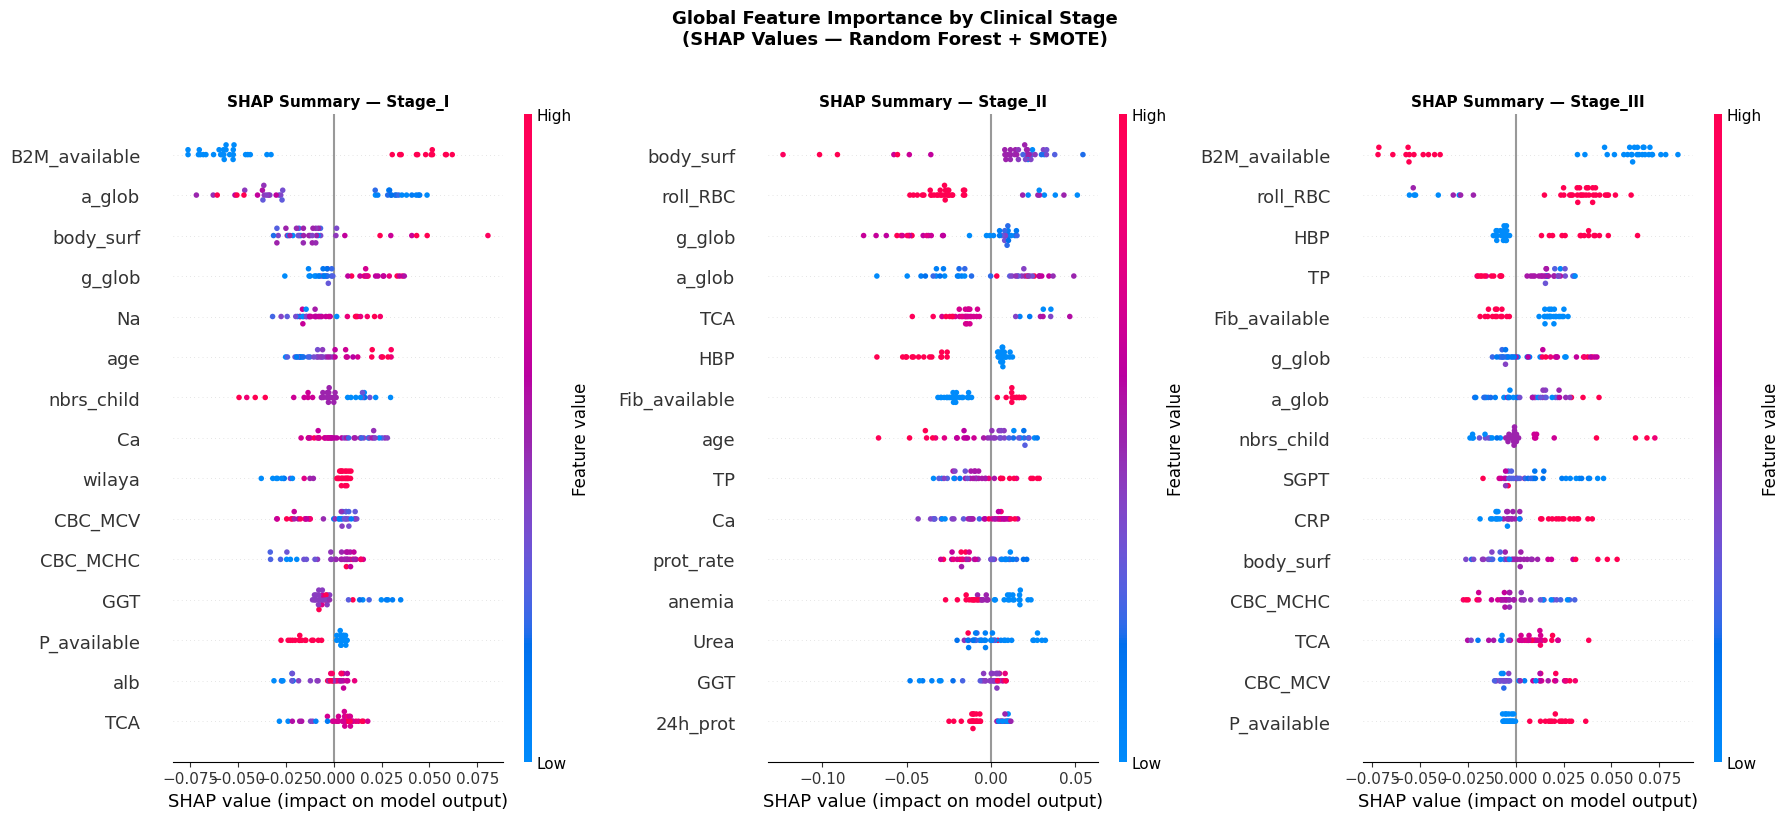

In [4]:
# =============================================================================
# SHAP SUMMARY PLOT — GLOBAL FEATURE IMPORTANCE
# =============================================================================
# The summary plot shows the most important features overall and how their
# values (high/low) affect the prediction for each class.
# Red = high feature value, Blue = low feature value.
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, (cls, ax) in enumerate(zip(le_target.classes_, axes)):
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i],
        X_test,
        feature_names=feature_cols,
        show=False,
        max_display=15,
        plot_size=None
    )
    ax.set_title(f'SHAP Summary — {cls}', fontweight='bold', fontsize=11)

plt.suptitle('Global Feature Importance by Clinical Stage\n(SHAP Values — Random Forest + SMOTE)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# =============================================================================
# CRITICAL LIMITATION: CLINICAL SELECTION BIAS
# =============================================================================
# B2M_available is the top predictive feature, but this reflects a
# clinical selection bias rather than true predictive power:
# B2M is only measured when the medical team already suspects advanced MM.
#
# This means the model is learning the diagnostic process bias,
# not the underlying disease biology.
#
# Consequence: the model would perform poorly in early detection or
# screening scenarios — precisely where AI could add the most value.
#
# Recommendation for future work: retrain the model excluding
# availability indicators, using only raw biomarker values,
# to assess true biological predictive power.
# =============================================================================
print("Critical limitation documented.")

Critical limitation documented.


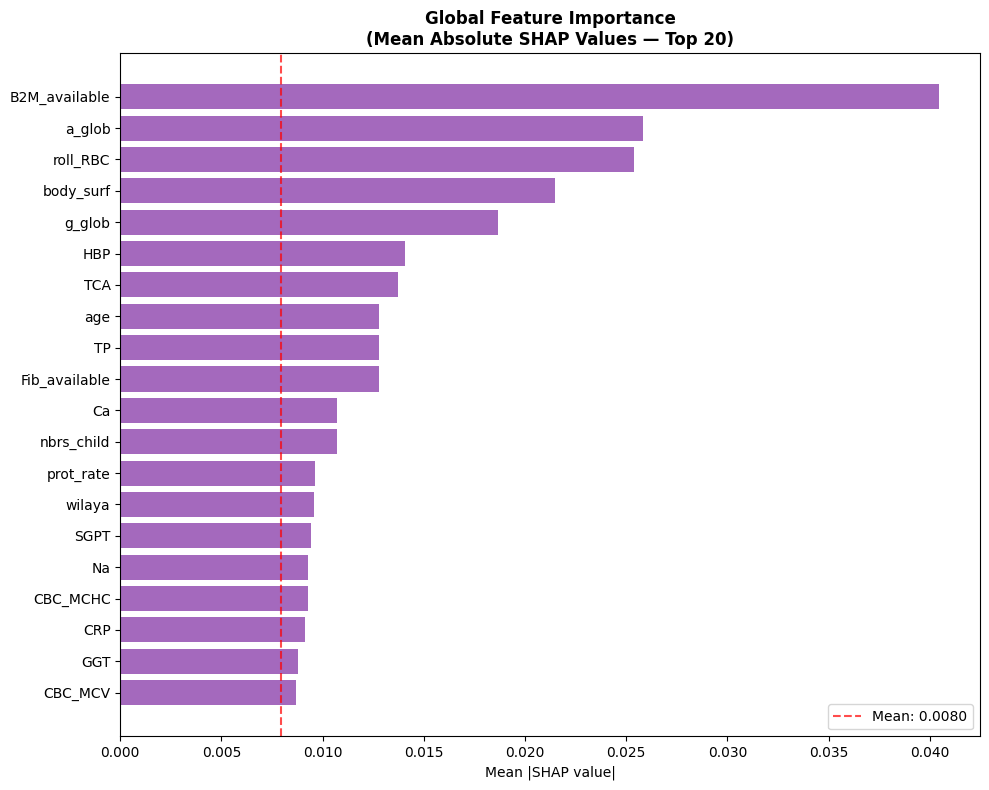


Top 10 most important features:
      feature  importance
B2M_available    0.040457
       a_glob    0.025818
     roll_RBC    0.025363
    body_surf    0.021479
       g_glob    0.018651
          HBP    0.014093
          TCA    0.013745
          age    0.012789
           TP    0.012775
Fib_available    0.012764


In [6]:
# =============================================================================
# SHAP BAR PLOT — GLOBAL FEATURE IMPORTANCE (mean absolute SHAP values)
# =============================================================================
# Mean absolute SHAP values across all samples and classes.
# This gives a single ranked list of the most influential features overall.
# =============================================================================

# Mean absolute SHAP values across all classes
shap_abs_mean = np.abs(shap_values).mean(axis=(0, 2))
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': shap_abs_mean
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feature_importance['feature'], 
               feature_importance['importance'],
               color='#8e44ad', alpha=0.8)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance\n(Mean Absolute SHAP Values — Top 20)',
             fontweight='bold')
ax.axvline(x=shap_abs_mean.mean(), color='red', linestyle='--', 
           alpha=0.7, label=f'Mean: {shap_abs_mean.mean():.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/shap_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 most important features:")
print(feature_importance.tail(10)[['feature', 'importance']].iloc[::-1].to_string(index=False))

In [7]:
# Select one representative patient per stage
stage_indices = {}
for i, cls in enumerate(le_target.classes_):
    idx = np.where(y_test == i)[0][0]
    stage_indices[cls] = idx

print("Selected patients for local explanation:")
for cls, idx in stage_indices.items():
    predicted = le_target.classes_[rf_best.predict(X_test.iloc[[idx]])[0]]
    actual = cls
    correct = "✅" if predicted == actual else "❌"
    print(f"  {cls}: patient index {idx} | predicted: {predicted} {correct}")

Selected patients for local explanation:
  Stage_I: patient index 1 | predicted: Stage_III ❌
  Stage_II: patient index 2 | predicted: Stage_III ❌
  Stage_III: patient index 0 | predicted: Stage_III ✅


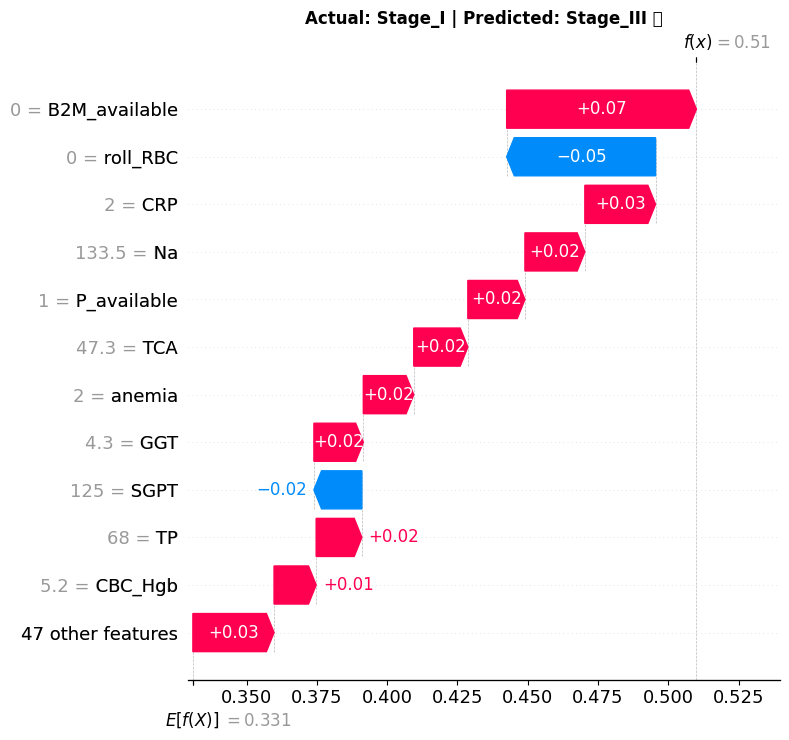

Saved: ../notebooks/shap_waterfall_Stage_I.png


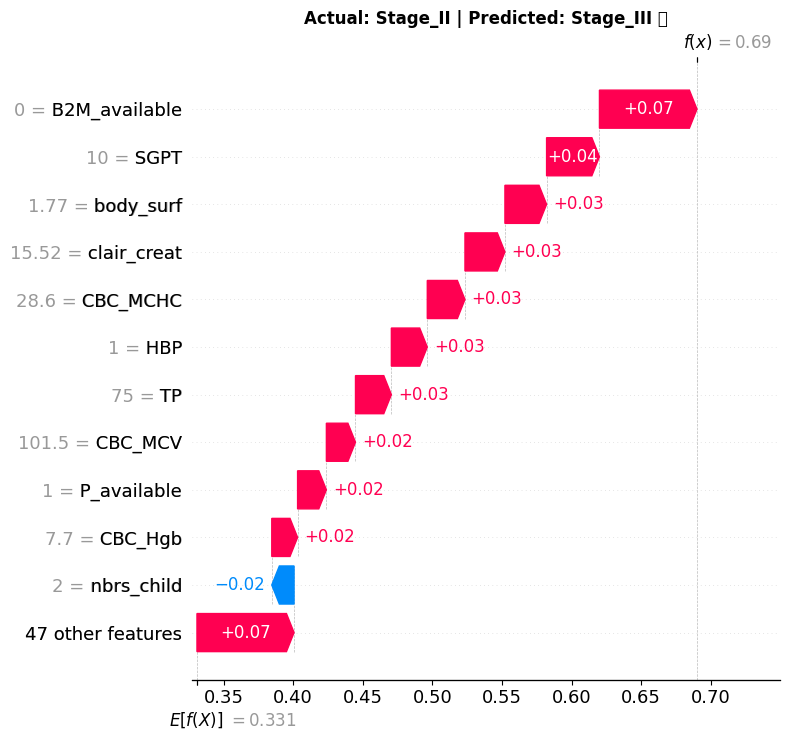

Saved: ../notebooks/shap_waterfall_Stage_II.png


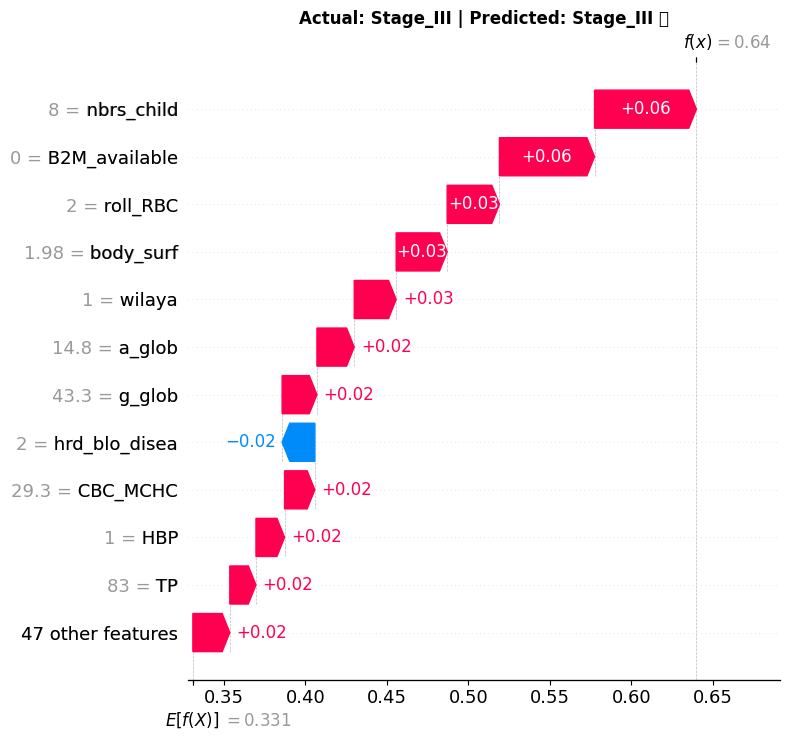

Saved: ../notebooks/shap_waterfall_Stage_III.png


In [8]:
# =============================================================================
# SHAP WATERFALL PLOTS — LOCAL EXPLANATIONS (one plot per patient)
# =============================================================================

for i, (cls, idx) in enumerate(stage_indices.items()):
    
    predicted_class_idx = rf_best.predict(X_test.iloc[[idx]])[0]
    shap_vals_patient = shap_values[idx, :, predicted_class_idx]
    
    explanation = shap.Explanation(
        values=shap_vals_patient,
        base_values=explainer.expected_value[predicted_class_idx],
        data=X_test.iloc[idx].values,
        feature_names=feature_cols
    )
    
    actual = cls
    predicted = le_target.classes_[predicted_class_idx]
    correct = "✅" if predicted == actual else "❌"
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f'Actual: {actual} | Predicted: {predicted} {correct}',
              fontweight='bold', fontsize=12)
    plt.tight_layout()
    path = f'../notebooks/shap_waterfall_{cls}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

In [9]:
# =============================================================================
# LOG SHAP ARTIFACTS TO MLFLOW
# =============================================================================

import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("file:///home/miguel/myeloma-explainability/mlruns")

client = MlflowClient()

# Find the RandomForest_SMOTE run
experiment = client.get_experiment_by_name("mm_stage_prediction")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'RandomForest_SMOTE'"
)
best_run_id = runs[0].info.run_id

# Log SHAP artifacts to the existing run
with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact('../notebooks/shap_summary_plot.png', artifact_path="plots/shap")
    mlflow.log_artifact('../notebooks/shap_feature_importance.png', artifact_path="plots/shap")
    for cls in ['Stage_I', 'Stage_II', 'Stage_III']:
        mlflow.log_artifact(f'../notebooks/shap_waterfall_{cls}.png', artifact_path="plots/shap")

print(f"SHAP plots logged to MLflow run: {best_run_id[:8]}...")
print("  ✅ shap_summary_plot.png")
print("  ✅ shap_feature_importance.png")
print("  ✅ shap_waterfall_Stage_I.png")
print("  ✅ shap_waterfall_Stage_II.png")
print("  ✅ shap_waterfall_Stage_III.png")

SHAP plots logged to MLflow run: b70f8ac8...
  ✅ shap_summary_plot.png
  ✅ shap_feature_importance.png
  ✅ shap_waterfall_Stage_I.png
  ✅ shap_waterfall_Stage_II.png
  ✅ shap_waterfall_Stage_III.png


In [11]:
# =============================================================================
# EXPERIMENT: REMOVING AVAILABILITY BIAS INDICATORS
# =============================================================================

from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE

# Features to exclude
bias_features = ['B2M_available', 'Fib_available', 'P_available', 'Ferr_available']
feature_cols_nobias = [f for f in feature_cols if f not in bias_features]

print(f"Removed bias features: {bias_features}")
print(f"Features: {len(feature_cols)} → {len(feature_cols_nobias)}")

# Prepare X without bias features
X_nobias = df_encoded[feature_cols_nobias]

# Train/test split
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nobias, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Apply SMOTE
smote_nb = SMOTE(random_state=42)
X_train_nb_smote, y_train_nb_smote = smote_nb.fit_resample(X_train_nb, y_train_nb)

# Train model
rf_nobias = RandomForestClassifier(n_estimators=100, random_state=42)
rf_nobias.fit(X_train_nb_smote, y_train_nb_smote)

# Evaluate
y_pred_nobias = rf_nobias.predict(X_test_nb)
f1_w_nobias = f1_score(y_test_nb, y_pred_nobias, average='weighted')
f1_m_nobias = f1_score(y_test_nb, y_pred_nobias, average='macro')

print(f"\n=== RESULTS COMPARISON ===")
print(f"RF + SMOTE (with bias)    — F1 weighted: 0.698 | F1 macro: 0.374")
print(f"RF + SMOTE (without bias) — F1 weighted: {f1_w_nobias:.3f} | F1 macro: {f1_m_nobias:.3f}")

print(f"\n=== CLASSIFICATION REPORT (without bias) ===")
print(classification_report(y_test_nb, y_pred_nobias, target_names=le_target.classes_))

Removed bias features: ['B2M_available', 'Fib_available', 'P_available', 'Ferr_available']
Features: 58 → 54

=== RESULTS COMPARISON ===
RF + SMOTE (with bias)    — F1 weighted: 0.698 | F1 macro: 0.374
RF + SMOTE (without bias) — F1 weighted: 0.719 | F1 macro: 0.484

=== CLASSIFICATION REPORT (without bias) ===
              precision    recall  f1-score   support

     Stage_I       0.20      0.20      0.20         5
    Stage_II       1.00      0.25      0.40         4
   Stage_III       0.81      0.90      0.85        29

    accuracy                           0.74        38
   macro avg       0.67      0.45      0.48        38
weighted avg       0.75      0.74      0.72        38



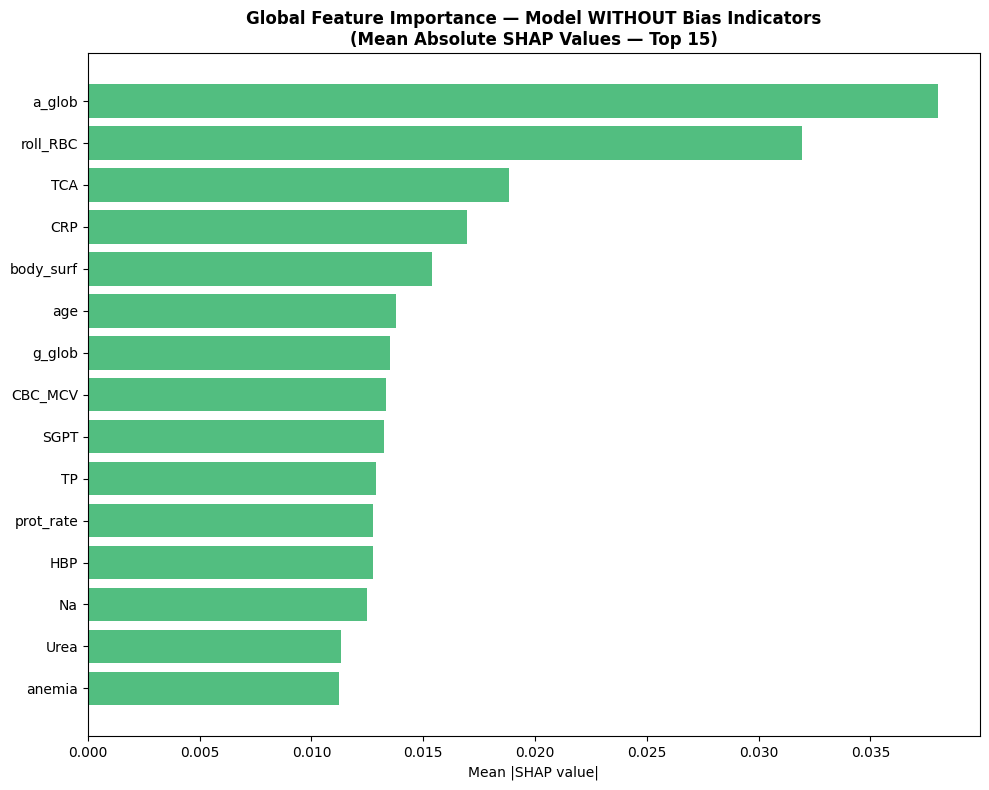


Top 10 most important features (without bias):
  feature  importance
   a_glob    0.038001
 roll_RBC    0.031951
      TCA    0.018817
      CRP    0.016936
body_surf    0.015413
      age    0.013763
   g_glob    0.013526
  CBC_MCV    0.013353
     SGPT    0.013223
       TP    0.012893


In [12]:
# =============================================================================
# SHAP ANALYSIS — MODEL WITHOUT BIAS INDICATORS
# =============================================================================
# Now that we removed the availability indicators, let's see which features
# the model uses instead — these should reflect true biological signal.
# =============================================================================

# Compute SHAP values for bias-free model
explainer_nobias = shap.TreeExplainer(rf_nobias)
shap_values_nobias = explainer_nobias.shap_values(X_test_nb)

# Mean absolute SHAP values
shap_abs_mean_nobias = np.abs(shap_values_nobias).mean(axis=(0, 2))
feature_importance_nobias = pd.DataFrame({
    'feature': feature_cols_nobias,
    'importance': shap_abs_mean_nobias
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance_nobias['feature'],
        feature_importance_nobias['importance'],
        color='#27ae60', alpha=0.8)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance — Model WITHOUT Bias Indicators\n(Mean Absolute SHAP Values — Top 15)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/shap_feature_importance_nobias.png', dpi=150)
plt.show()

print("\nTop 10 most important features (without bias):")
print(feature_importance_nobias.tail(10)[['feature', 'importance']].iloc[::-1].to_string(index=False))

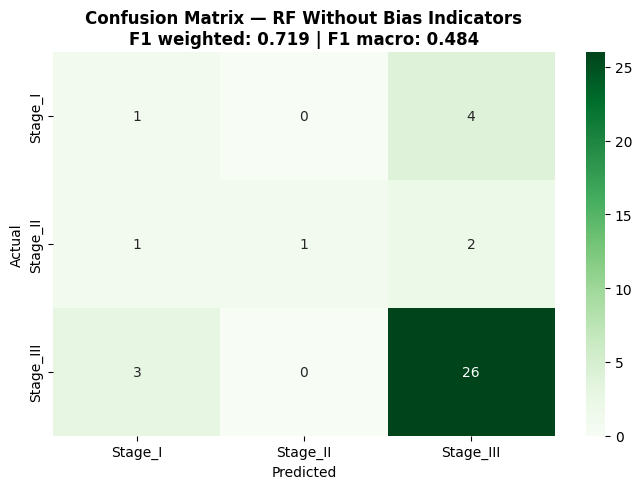


=== CLASSIFICATION REPORT — WITHOUT BIAS INDICATORS ===
              precision    recall  f1-score   support

     Stage_I       0.20      0.20      0.20         5
    Stage_II       1.00      0.25      0.40         4
   Stage_III       0.81      0.90      0.85        29

    accuracy                           0.74        38
   macro avg       0.67      0.45      0.48        38
weighted avg       0.75      0.74      0.72        38



In [17]:
# =============================================================================
# CONFUSION MATRIX — MODEL WITHOUT BIAS INDICATORS
# =============================================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

plt.close('all')

fig, ax = plt.subplots(figsize=(7, 5))
cm_nobias = confusion_matrix(y_test_nb, y_pred_nobias)
sns.heatmap(cm_nobias, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=ax)
ax.set_title('Confusion Matrix — RF Without Bias Indicators\nF1 weighted: 0.719 | F1 macro: 0.484',
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix_nobias.png', dpi=150)
plt.show()

print("\n=== CLASSIFICATION REPORT — WITHOUT BIAS INDICATORS ===")
print(classification_report(y_test_nb, y_pred_nobias, target_names=le_target.classes_))

In [19]:
# =============================================================================
# INDIVIDUAL PREDICTION TEST — SYNTHETIC PATIENTS
# =============================================================================
# We create synthetic patients with clinical profiles typical of each stage
# to test how the bias-free model responds to biological signals.
# =============================================================================

# Get median values from training data as baseline
baseline = X_train_nb.median()

# Create 3 synthetic patients based on Durie-Salmon criteria
patients = {
    'Typical_Stage_I': baseline.copy(),
    'Typical_Stage_II': baseline.copy(),
    'Typical_Stage_III': baseline.copy()
}

# Stage I profile — low tumor burden
# Hgb > 10, normal calcium, low protein
patients['Typical_Stage_I']['CBC_Hgb'] = 11.5
patients['Typical_Stage_I']['Ca'] = 90.0
patients['Typical_Stage_I']['prot_rate'] = 30.0
patients['Typical_Stage_I']['creat'] = 10.0
patients['Typical_Stage_I']['roll_RBC'] = 0  # no rouleaux
patients['Typical_Stage_I']['a_glob'] = 3.0
patients['Typical_Stage_I']['g_glob'] = 10.0

# Stage III profile — high tumor burden
# Hgb < 8.5, high calcium, high protein, kidney failure
patients['Typical_Stage_III']['CBC_Hgb'] = 7.5
patients['Typical_Stage_III']['Ca'] = 130.0
patients['Typical_Stage_III']['prot_rate'] = 120.0
patients['Typical_Stage_III']['creat'] = 35.0
patients['Typical_Stage_III']['roll_RBC'] = 1  # rouleaux present
patients['Typical_Stage_III']['a_glob'] = 8.0
patients['Typical_Stage_III']['g_glob'] = 35.0

# Stage II profile — intermediate
patients['Typical_Stage_II']['CBC_Hgb'] = 9.5
patients['Typical_Stage_II']['Ca'] = 100.0
patients['Typical_Stage_II']['prot_rate'] = 70.0
patients['Typical_Stage_II']['creat'] = 18.0
patients['Typical_Stage_II']['roll_RBC'] = 1
patients['Typical_Stage_II']['a_glob'] = 5.0
patients['Typical_Stage_II']['g_glob'] = 22.0

# Predict
print("=== SYNTHETIC PATIENT PREDICTIONS ===\n")
for name, patient in patients.items():
    patient_df = pd.DataFrame([patient], columns=feature_cols_nobias)
    pred_idx = rf_nobias.predict(patient_df)[0]
    pred_proba = rf_nobias.predict_proba(patient_df)[0]
    pred_class = le_target.classes_[pred_idx]
    
    print(f"{name}:")
    print(f"  Predicted: {pred_class}")
    for cls, prob in zip(le_target.classes_, pred_proba):
        bar = '█' * int(prob * 20)
        print(f"  {cls:12s}: {prob:.2f} {bar}")
    print()

=== SYNTHETIC PATIENT PREDICTIONS ===

Typical_Stage_I:
  Predicted: Stage_I
  Stage_I     : 0.51 ██████████
  Stage_II    : 0.20 ████
  Stage_III   : 0.29 █████

Typical_Stage_II:
  Predicted: Stage_I
  Stage_I     : 0.54 ██████████
  Stage_II    : 0.21 ████
  Stage_III   : 0.25 █████

Typical_Stage_III:
  Predicted: Stage_I
  Stage_I     : 0.59 ███████████
  Stage_II    : 0.10 ██
  Stage_III   : 0.31 ██████



In [20]:
# =============================================================================
# INDIVIDUAL PREDICTION TEST — REAL PATIENTS FROM TEST SET
# =============================================================================
# Testing model predictions on real patients from the test set,
# selecting one correctly and one incorrectly classified per stage.
# =============================================================================

print("=== REAL PATIENT PREDICTIONS ===\n")
for i, cls in enumerate(le_target.classes_):
    # Get all patients of this class in test set
    class_indices = np.where(y_test_nb == i)[0]
    
    for idx in class_indices:
        patient_df = X_test_nb.iloc[[idx]]
        pred_idx = rf_nobias.predict(patient_df)[0]
        pred_proba = rf_nobias.predict_proba(patient_df)[0]
        pred_class = le_target.classes_[pred_idx]
        correct = "✅" if pred_idx == i else "❌"
        
        print(f"Actual: {cls} | Predicted: {pred_class} {correct}")
        for c, prob in zip(le_target.classes_, pred_proba):
            bar = '█' * int(prob * 20)
            print(f"  {c:12s}: {prob:.2f} {bar}")
        print()

=== REAL PATIENT PREDICTIONS ===

Actual: Stage_I | Predicted: Stage_I ✅
  Stage_I     : 0.44 ████████
  Stage_II    : 0.15 ███
  Stage_III   : 0.41 ████████

Actual: Stage_I | Predicted: Stage_III ❌
  Stage_I     : 0.16 ███
  Stage_II    : 0.30 ██████
  Stage_III   : 0.54 ██████████

Actual: Stage_I | Predicted: Stage_III ❌
  Stage_I     : 0.30 ██████
  Stage_II    : 0.11 ██
  Stage_III   : 0.59 ███████████

Actual: Stage_I | Predicted: Stage_III ❌
  Stage_I     : 0.26 █████
  Stage_II    : 0.32 ██████
  Stage_III   : 0.42 ████████

Actual: Stage_I | Predicted: Stage_III ❌
  Stage_I     : 0.24 ████
  Stage_II    : 0.22 ████
  Stage_III   : 0.54 ██████████

Actual: Stage_II | Predicted: Stage_III ❌
  Stage_I     : 0.20 ████
  Stage_II    : 0.09 █
  Stage_III   : 0.71 ██████████████

Actual: Stage_II | Predicted: Stage_III ❌
  Stage_I     : 0.43 ████████
  Stage_II    : 0.10 ██
  Stage_III   : 0.47 █████████

Actual: Stage_II | Predicted: Stage_II ✅
  Stage_I     : 0.25 █████
  Stage_II

In [21]:
# =============================================================================
# SAVE BEST MODEL (WITHOUT BIAS INDICATORS)
# =============================================================================
# Save the bias-free model and the feature list to disk for deployment.
# =============================================================================

import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save model
joblib.dump(rf_nobias, '../models/rf_nobias.joblib')

# Save feature list and label encoder
joblib.dump(feature_cols_nobias, '../models/feature_cols_nobias.joblib')
joblib.dump(le_target, '../models/le_target.joblib')

print("Model saved to models/rf_nobias.joblib")
print("Features saved to models/feature_cols_nobias.joblib")
print("Label encoder saved to models/le_target.joblib")

Model saved to models/rf_nobias.joblib
Features saved to models/feature_cols_nobias.joblib
Label encoder saved to models/le_target.joblib
